In [2]:
%pip install nltk 

  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [n

In [6]:
import numpy as np 
import pandas as pd 

In [3]:
import nltk 
import re 
nltk.download('stopwords') 
from nltk.corpus import stopwords 
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [7]:
df=pd.read_csv('C:\\Users\\acer\\Downloads\\Restaurant_Reviews.tsv',delimiter='\t', quoting=3) 
df.head() 

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [3]:
df.shape 

(1000, 2)

In [10]:
corpus = [] 
for i in range(0,1000): 
    # Cleaning special character from the reviews  
    review = re.sub(pattern='[^a-zA-Z]',repl=' ', string=df['Review'][i]) 
    # Converting the entire review into lower case 
    review = review.lower() 
    # Tokenizing the review by words 
    review_words = review.split() 
    # Removing the stop words 
    review_words = [word for word in review_words if not word in set(stopwords.words('english'))] 
    # Stemming the words 
    ps = PorterStemmer() 
    review = [ps.stem(word) for word in review_words] 
    # Joining the stemmed words 
    review = ' '.join(review) 
    # Creating a corpus 
    corpus.append(review) 
print(corpus[0:10])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [13]:
# Creating the Bag of Words model 
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500) 
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, 1].values

In [14]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state = 0) 
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(n_estimators=35) 
model.fit(X_train, y_train) 
RandomForestClassifier(n_estimators=35) 
model.score(X_test, y_test) 

0.7

In [15]:
# Predicting the Test set results 
y_pred = model.predict(X_test) # Accuracy, Precision and Recall 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score 
from sklearn.metrics import recall_score 
score1 = accuracy_score(y_test,y_pred) 
score2 = precision_score(y_test,y_pred) 
score3= recall_score(y_test,y_pred) 
print("---- Scores ---- ") 
print("Accuracy score is: {}%".format(round(score1*100,2))) 
print("Precision score is: {}".format(round(score2,2))) 
print("Recall score is: {}".format(round(score3,2))) 

---- Scores ---- 
Accuracy score is: 70.0%
Precision score is: 0.81
Recall score is: 0.54


Text(32.88563368055555, 0.5, 'Actual values')

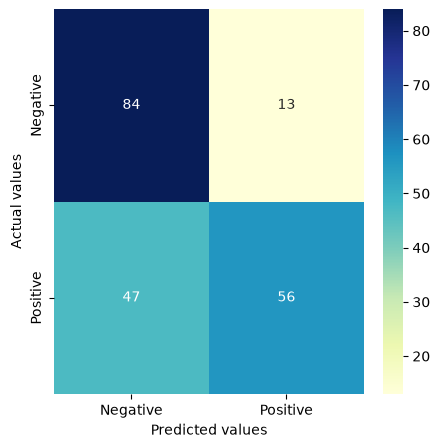

In [17]:
# Making the Confusion Matrix 
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test, y_pred) 
# Plotting the confusion matrix 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 
plt.figure(figsize = (5,5)) 
sns.heatmap(cm, annot=True, cmap="YlGnBu", xticklabels=['Negative','Positive'], yticklabels=['Negative', 'Positive']) 
plt.xlabel('Predicted values') 
plt.ylabel('Actual values') 

In [20]:
# Hyperparameter tuning the Naive Bayes Classifier
best_accuracy = 0.0 
n_estimators = 5 
for i in np.arange(1,30,2): 
    temp_classifier = RandomForestClassifier(n_estimators=i) 
    temp_classifier.fit(X_train, y_train) 
    temp_y_pred = temp_classifier.predict(X_test) 
    score = accuracy_score(y_test, temp_y_pred) 
    print("Accuracy score for n_estimators={} is: {}%".format(round(i,1),round(score*100,2)))
    if score>best_accuracy: 
        best_accuracy = score 
        n_estimators_val = i 
    print(' ') 
print('The best accuracy is {}% with n_estimators value as {}'.format(round(best_accuracy*100,2), round(n_estimators_val,1))) 

Accuracy score for n_estimators=1 is: 63.5%
 
Accuracy score for n_estimators=3 is: 62.5%
 
Accuracy score for n_estimators=5 is: 69.5%
 
Accuracy score for n_estimators=7 is: 68.5%
 
Accuracy score for n_estimators=9 is: 69.5%
 
Accuracy score for n_estimators=11 is: 70.5%
 
Accuracy score for n_estimators=13 is: 66.5%
 
Accuracy score for n_estimators=15 is: 70.5%
 
Accuracy score for n_estimators=17 is: 71.5%
 
Accuracy score for n_estimators=19 is: 68.5%
 
Accuracy score for n_estimators=21 is: 70.5%
 
Accuracy score for n_estimators=23 is: 71.5%
 
Accuracy score for n_estimators=25 is: 71.5%
 
Accuracy score for n_estimators=27 is: 68.5%
 
Accuracy score for n_estimators=29 is: 69.5%
 
The best accuracy is 71.5% with n_estimators value as 17


In [21]:
model = RandomForestClassifier(n_estimators=n_estimators_val) 
model.fit(X_train, y_train) 
RandomForestClassifier(n_estimators=19) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",19
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [23]:
def predict_sentiment(sample_review): 
    sample_review = re.sub(pattern='[^a-zA-Z]',repl=' ', string =sample_review) 
    sample_review = sample_review.lower() 
    sample_review_words = sample_review.split() 
    sample_review_words = [word for word in sample_review_words if not word in set(stopwords.words('english'))] 
    ps = PorterStemmer() 
    final_review = [ps.stem(word) for word in sample_review_words]
    final_review = ' '.join(final_review) 
    temp = cv.transform([final_review]).toarray()
    return model.predict(temp)

In [24]:
sample_review = 'The food is really good here.' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a POSITIVE review.


In [25]:
sample_review = 'Food was pretty bad and the service was very slow.' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a NEGATIVE review!


In [26]:
sample_review = 'The food was absolutely wonderful and nicely presentation' 
if predict_sentiment(sample_review): 
    print('This is a POSITIVE review.') 
else: 
    print('This is a NEGATIVE review!') 

This is a POSITIVE review.
